In [15]:
### 1. 기본 데이터 처리 및 시각화
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 및 마이너스 기호 처리
plt.rc("font", family="Malgun Gothic") # Mac: AppleGothic
plt.rcParams["axes.unicode_minus"] = False


### 2. 데이터 전처리 및 분석
from scipy.stats import spearmanr, pearsonr
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, PolynomialFeatures
from imblearn.over_sampling import SMOTE


### 3. 머신러닝 모델 (회귀 - Regressor)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import (
    RandomForestRegressor, 
    ExtraTreesRegressor, 
    GradientBoostingRegressor, 
    HistGradientBoostingRegressor
)
from xgboost import XGBRegressor


### 4. 머신러닝 모델 (분류 - Classifier)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier, 
    ExtraTreesClassifier, 
    GradientBoostingClassifier, 
    HistGradientBoostingClassifier
)
from xgboost import XGBClassifier


### 5. 모델 평가 지표
# 회귀 평가
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 분류 평가
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)

# 모델 저장
import joblib

from sklearn.metrics import classification_report
from sklearn.metrics import average_precision_score

In [2]:
# SAS 파일 읽기
file_path14 = './datas/hn14_all.sas7bdat'
file_path15 = './datas/hn15_all.sas7bdat'
file_path16 = './datas/hn16_all.sas7bdat'
file_path17 = './datas/hn17_all.sas7bdat'
file_path18 = './datas/hn18_all.sas7bdat'
file_path19 = './datas/hn19_all.sas7bdat'
file_path20 = './datas/hn20_all.sas7bdat'
file_path21 = './datas/hn21_all.sas7bdat'
file_path22 = './datas/hn22_all.sas7bdat'
file_path23 = './datas/hn23_all.sas7bdat'
file_path24 = './datas/hn24_all.sas7bdat'

df14 = pd.read_sas(file_path14, format='sas7bdat', encoding='latin1') 
df15 = pd.read_sas(file_path15, format='sas7bdat', encoding='latin1') 
df16 = pd.read_sas(file_path16, format='sas7bdat', encoding='latin1') 
df17 = pd.read_sas(file_path17, format='sas7bdat', encoding='latin1') 
df18 = pd.read_sas(file_path18, format='sas7bdat', encoding='latin1') 
df19 = pd.read_sas(file_path19, format='sas7bdat', encoding='latin1') 
df20 = pd.read_sas(file_path20, format='sas7bdat', encoding='latin1') 
df21 = pd.read_sas(file_path21, format='sas7bdat', encoding='latin1') 
df22 = pd.read_sas(file_path22, format='sas7bdat', encoding='latin1') 
df23 = pd.read_sas(file_path23, format='sas7bdat', encoding='latin1') 
df24 = pd.read_sas(file_path24, format='sas7bdat', encoding='latin1') 


file_path13 = "./datas/hn13_all.sas7bdat"
file_path12 = "./datas/hn12_all.sas7bdat"
file_path11 = "./datas/hn11_all.sas7bdat"
file_path10 = "./datas/hn10_all.sas7bdat"
file_path9 = "./datas/hn09_all.sas7bdat"
file_path8 = "./datas/hn08_all.sas7bdat"
file_path7 = "./datas/hn07_all.sas7bdat"
file_path5 = "./datas/hn05_all.sas7bdat"

df13 = pd.read_sas(file_path13, format='sas7bdat', encoding='latin1') 
df12 = pd.read_sas(file_path12, format='sas7bdat', encoding='latin1') 
df11 = pd.read_sas(file_path11, format='sas7bdat', encoding='latin1') 
df10 = pd.read_sas(file_path10, format='sas7bdat', encoding='latin1') 
df9 = pd.read_sas(file_path9, format='sas7bdat', encoding='latin1') 
df8 = pd.read_sas(file_path8, format='sas7bdat', encoding='latin1') 
df7 = pd.read_sas(file_path7, format='sas7bdat', encoding='latin1') 
df5 = pd.read_sas(file_path5, format='sas7bdat', encoding='latin1') 


In [3]:
# 1. 모든 데이터프레임을 리스트로 묶습니다.
df_list = [df14, df15, df16, df17, df18, df19, df20, df21, df22, df23, df24]

# 2. 한 번에 위아래로 합칩니다.
df_total = pd.concat(df_list, ignore_index=True)

# 1. 모든 데이터프레임을 리스트로 묶습니다.
df_list1 = [df13,df12,df11,df10,df9 ,df8 ,df7 ,df5 ]

# 2. 한 번에 위아래로 합칩니다.
df_total1 = pd.concat(df_list, ignore_index=True)

In [4]:
### "DI4_dg","DI5_dg" 이 두개 컬럼을 종속변수로 둠
# DI4_dg = 심근경색증 또는 혐심증 의사 진단 여부(0.없음, 1.있음, 8.비해당)
# DI5_dg = 심근경색증 의사 진단 여부(0.없음, 1.있음, 8.비해당, 9.모름, 무응답)

data = df_total[["DI4_dg", "DI5_dg", "DI1_dg", "DI2_dg", "DE1_dg", "DI3_dg", "HE_HP",  "HE_glu", "HE_HbA1c", "HE_chol", "HE_TG", "HE_BMI", "HE_wc",
               "BS1_1", "BD1_11", "BD2_1", "BE8_1", "pa_aerobic",
               "sex", "age", "edu", "ho_incm"]]


In [5]:
# 심근경색걸린사람 추가 데이터
df_one_data = df_total1[df_total1["DI4_dg"] == 1].copy()

df_total2 = df_one_data[["DI4_dg", "DI5_dg", "DI1_dg", "DI2_dg", "DE1_dg", "DI3_dg", "HE_HP",  "HE_glu", "HE_HbA1c", "HE_chol", "HE_TG", "HE_BMI", "HE_wc",
               "BS1_1", "BD1_11", "BD2_1", "BE8_1", "pa_aerobic",
               "sex", "age", "edu", "ho_incm"]].dropna()

In [6]:
# ------> 8을 0으로 바꿈 9의 데이턴는 삭제
col_replace = ["DI1_dg", "DI2_dg", "DE1_dg", "DI3_dg"]
# ------> 8을 1으로 바꿈 9의 데이턴는 삭제
col_replace2 = ["BD1_11"]
# ------> 9의 데이턴는 삭제
col_replace3 = ["BD2_1"]

for col in col_replace:
    if col in data.columns:
        # 비해당 → 0
        data[col] = data[col].replace(8, 0)
        # 모름/무응답 → 행 삭제
        data = data[data[col] != 9]      

for col in col_replace2:
    if col in data.columns:
        data[col] = data[col].replace(8, 1)
        data = data[data[col] != 9]
data = data[data["BD2_1"] != 9]



# ------> 8을 0으로 바꿈 9의 데이턴는 삭제
col_replace = ["DI1_dg", "DI2_dg", "DE1_dg", "DI3_dg"]
# ------> 8을 1으로 바꿈 9의 데이턴는 삭제
col_replace2 = ["BD1_11"]
# ------> 9의 데이턴는 삭제
col_replace3 = ["BD2_1"]

for col in col_replace:
    if col in df_total2.columns:
        # 비해당 → 0
        df_total2[col] = df_total2[col].replace(8, 0)
        # 모름/무응답 → 행 삭제
        df_total2 = df_total2[df_total2[col] != 9]      

for col in col_replace2:
    if col in df_total2.columns:
        df_total2[col] = df_total2[col].replace(8, 1)
        df_total2 = df_total2[df_total2[col] != 9]
df_total2 = df_total2[df_total2["BD2_1"] != 9]

C:\Users\Administrator\AppData\Local\Temp\ipykernel_14068\335055933.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col] = data[col].replace(8, 0)


In [7]:
data = data.dropna()

In [8]:
df_list2 = [data, df_total2]
datall = pd.concat(df_list2, ignore_index=True)

In [9]:
# 1. 0과 1 데이터를 분리
df_0 = datall[datall["DI4_dg"] == 0]
df_1 = datall[datall["DI4_dg"] == 1]

# 2. 0의 데이터를 10,000개로 언더샘플링
df_0_downsampled = df_0.sample(n=10000, random_state=42)

# 3. 다시 합치기
df_combined = pd.concat([df_0_downsampled, df_1], axis=0)

In [10]:
# 독립변수(X)와 종속변수(y) 분리
X = df_combined.drop("DI4_dg", axis=1)
y = df_combined["DI4_dg"]

# SMOTE 설정 (sampling_strategy를 통해 타겟 개수 지정 가능)
# 0이 10,000개이므로 'auto'로 설정하면 1도 10,000개로 맞춰집니다.
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# 결과 확인을 위해 다시 데이터프레임으로 결합
df_final = pd.concat([pd.DataFrame(X_resampled), pd.DataFrame(y_resampled, columns=["DI4_dg"])], axis=1)

print(df_final["DI4_dg"].value_counts())

DI4_dg
0.0    10000
1.0    10000
Name: count, dtype: int64


In [11]:
target2 = df_final["DI4_dg"]
datas2 = df_final[["DI1_dg", "DI2_dg", "DE1_dg", "DI3_dg", "HE_HP",  "HE_glu", "HE_HbA1c", "HE_chol", "HE_TG", "HE_BMI", "HE_wc",
               "BS1_1", "BD1_11", "BD2_1", "BE8_1", "pa_aerobic",
               "sex", "age", "edu", "ho_incm"]]

In [12]:
X = datas2
y = target2

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

ss = StandardScaler()
ss.fit(X_train)
X_train_scale = ss.transform(X_train)
X_test_scale = ss.transform(X_test)

print(X_train_scale.shape, X_test_scale.shape)


(16000, 20) (4000, 20)


In [16]:
# 모델 생성
model = XGBClassifier(   
    random_state=42
)

# 학습
model.fit(X_train_scale, y_train)

# 확률 예측
lr_test_pred = model.predict(X_test_scale)
y_probs = model.predict_proba(X_test_scale)[:, 1]

print(classification_report(y_test, lr_test_pred))

# PR-AUC
ap = average_precision_score(y_test, y_probs)
print("PR-AUC:", ap)

              precision    recall  f1-score   support

         0.0       0.96      0.90      0.93      2019
         1.0       0.91      0.96      0.93      1981

    accuracy                           0.93      4000
   macro avg       0.93      0.93      0.93      4000
weighted avg       0.93      0.93      0.93      4000

PR-AUC: 0.9834430364306379


In [22]:
y_probs = model.predict_proba(X_test_scale)
y_probs

array([[0.1913346 , 0.8086654 ],
       [0.5927125 , 0.40728748],
       [0.9927834 , 0.00721659],
       ...,
       [0.06758642, 0.9324136 ],
       [0.9870823 , 0.0129177 ],
       [0.4845413 , 0.5154587 ]], shape=(4000, 2), dtype=float32)

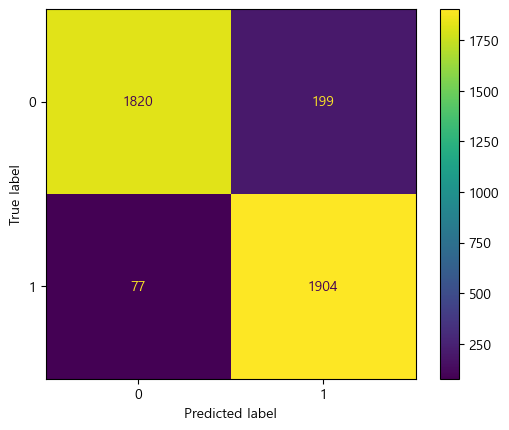

In [18]:
# 오차행렬 계산
cm = confusion_matrix(y_test, lr_test_pred)

# 오차행렬 시각화
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()
plt.show()

In [24]:
extramodel = ExtraTreesClassifier(n_estimators = 50, max_depth = None, min_samples_split = 2, min_samples_leaf = 1)
# 학습
extramodel.fit(X_train_scale, y_train)

# 확률 예측
lr_test_pred = model.predict(X_test_scale)
y_probs = model.predict_proba(X_test_scale)[:, 1]



print(classification_report(y_test, lr_test_pred))


              precision    recall  f1-score   support

         0.0       0.96      0.90      0.93      2019
         1.0       0.91      0.96      0.93      1981

    accuracy                           0.93      4000
   macro avg       0.93      0.93      0.93      4000
weighted avg       0.93      0.93      0.93      4000



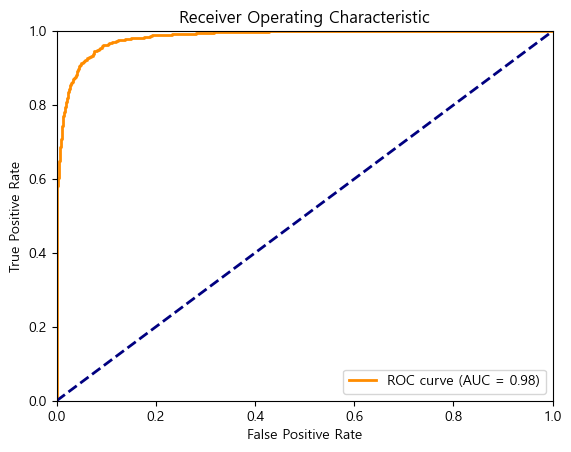

In [20]:
from sklearn.metrics import roc_curve, auc

# ROC 곡선 계산
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# AUC 계산
roc_auc = auc(fpr, tpr)

# ROC 곡선 그리기
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

In [ ]:
# 오차행렬 계산
cm = confusion_matrix(y_test, lr_test_pred)

# 오차행렬 시각화
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()
plt.show()

In [ ]:
# 모델 저장
# save_path = "./model/heart_predict_model.pkl"
# joblib.dump(extramodel, save_path)